# Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

# Helper Functions

In [2]:
def voigt_profile_single(x, A1, centre1, gamma1, sigma1, offset):
    return(A1*voigt_profile(x - centre1, sigma1, gamma1) + offset)

def voigt_model_double(x, A1, center1, gamma1, sigma1,
                       A2, delta, gamma2, sigma2, offset):

    return (
        A1 * voigt_profile(x - center1, sigma1, gamma1) +
        A2 * voigt_profile(x - (center1 + delta), sigma2, gamma2) +
        offset
    )

def lorentzian_profile(x, gamma):
    return gamma / (np.pi * (x**2 + gamma**2))

def lorentzian_single_model(x, A, center, gamma, offset):
    return A*lorentzian_profile(x- center, gamma) + offset


def lorentzian_model_double(x, A1, center1, gamma1,
                            A2, delta, gamma2, offset):

    return (
        A1 * lorentzian_profile(x - center1, gamma1) +
        A2 * lorentzian_profile(x - (center1 + delta), gamma2) +
        offset
    )

def gaussian_profile(x, sigma):
    return (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-(x**2)/(2*sigma**2))

def gaussian_single_model(x, A, center, sigma, offset):
    return A * gaussian_profile(x - center, sigma) + offset

def gaussian_model_double(x, A1, center1, sigma1,
                          A2, delta, sigma2, offset):

    return (
        A1 * gaussian_profile(x - center1, sigma1) +
        A2 * gaussian_profile(x - (center1 + delta), sigma2) +
        offset
    )




def reduced_chi_squared_calc(model, model_params, xdata, ydata, yerror):
    dof = len(xdata)-len(model_params)
    theoretical = model(xdata,*model_params)
    chi2 = np.sum((theoretical - ydata)**2/(yerror**2))
    rchi2 = chi2/dof
    return chi2, rchi2

def residual_calculator(xdata, ydata, yerr, model, model_params):
    fit = model(xdata, *model_params)
    residual = ydata - fit
    norm_residual = residual/yerr
    return  norm_residual

def wavelength_extraction(x, start_index):
    A = 0.9958
    B = 9096.6280
    return (start_index - 0.242 * x - B) / A




def normalise_spectra(df, cols, wavelengths):
    dx = np.abs(wavelengths[1] - wavelengths[0])
    area_0 = np.sum(df[cols[0]] * dx)

    normalised = []

    for col in cols:
        spec = df[col].to_numpy()
        norm = (spec / np.sum(spec * dx)) * area_0
        normalised.append(norm)

    matrix = np.column_stack(normalised)

    mean_intensity = np.mean(matrix, axis=1)
    error = np.std(matrix, axis=1) / np.sqrt(len(cols))

    return normalised, mean_intensity, error

# Data Sets

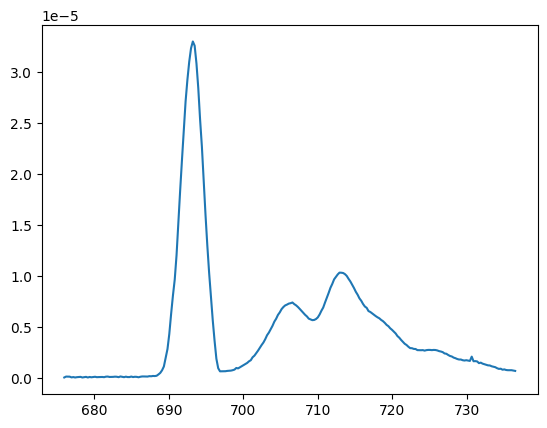

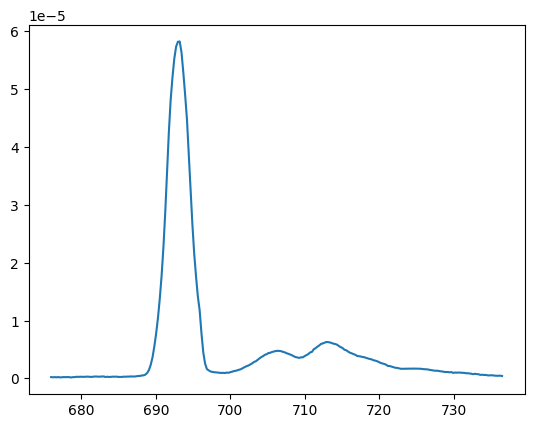

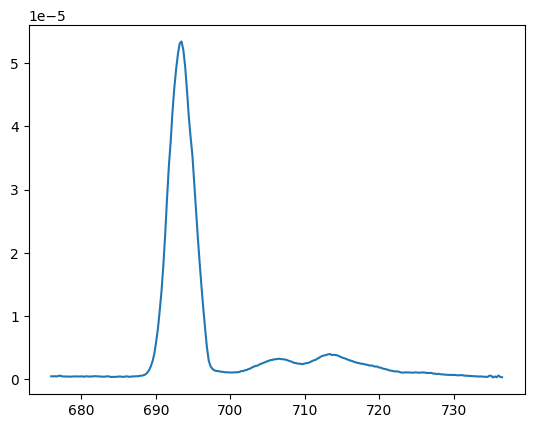

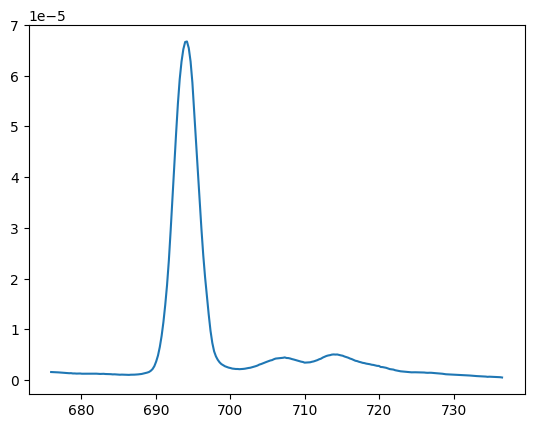

In [15]:
# Monochromator

mono_file = "Monodchromator_Data_Initialisation.xlsx"

df = pd.read_excel(mono_file)

indexes = np.arange(0, 250, 1)
wavelengths = wavelength_extraction(indexes, 9830)


I_77_normalised, I_77_mean, I_77_err = normalise_spectra(df, ["77_0", "77_1"], wavelengths)
I_147_normalised, I_147_mean, I_147_err = normalise_spectra(df, ["147_0", "147_1"], wavelengths)
I_217_normalised, I_217_mean, I_217_err = normalise_spectra(df, ["217_0", "217_1"], wavelengths)
I_298_normalised, I_298_mean, I_298_err = normalise_spectra(df, ["298_0", "298_1", "298_2", "298_3", "298_4", "298_5", "298_6", "298_7", "298_8", "298_9"], wavelengths)

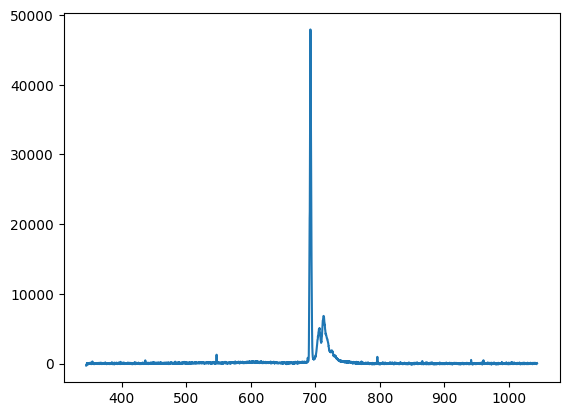

In [9]:
# Ocean Optics

ocean_file = "Ocean_Opt_Data.xlsx"

df_ocean = pd.read_excel(ocean_file)

x_ocean_77 = df_ocean["W_77"].to_numpy()
x_ocean_147 = df_ocean["W_130"].to_numpy()
x_ocean_217 = df_ocean["W_217"].to_numpy()
x_ocean_298 = df_ocean["W_298"].to_numpy()

y_ocean_77 = df_ocean["I_77"].to_numpy()
y_ocean_147 = df_ocean["I_130"].to_numpy()
y_ocean_217 = df_ocean["I_217"].to_numpy()
y_ocean_298 = df_ocean["I_298"].to_numpy()

plt.figure(1)
plt.plot(x_ocean_77, y_ocean_77)

plt.show()

----- Mono -----


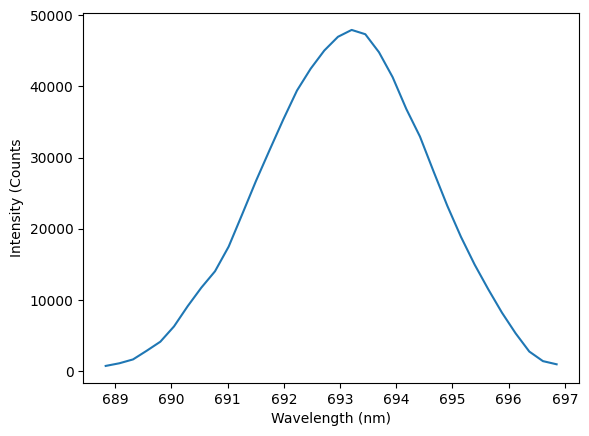

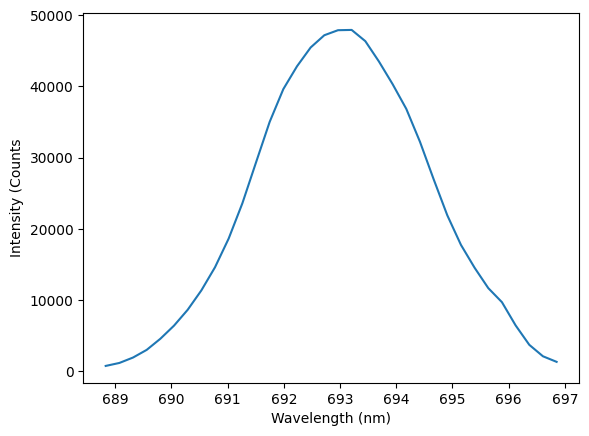

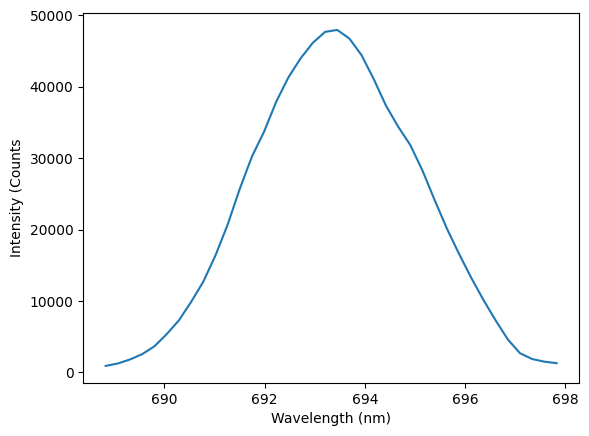

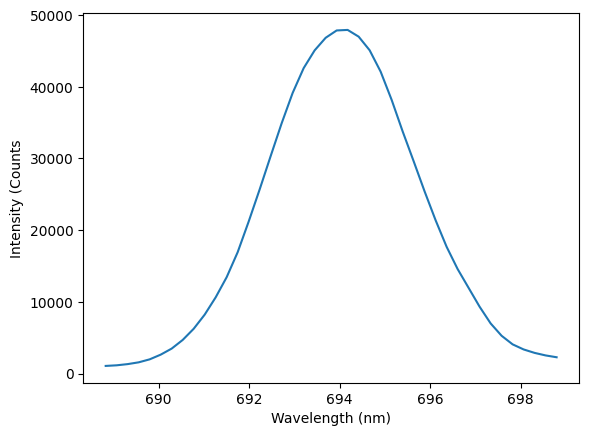

----- Ocean -----


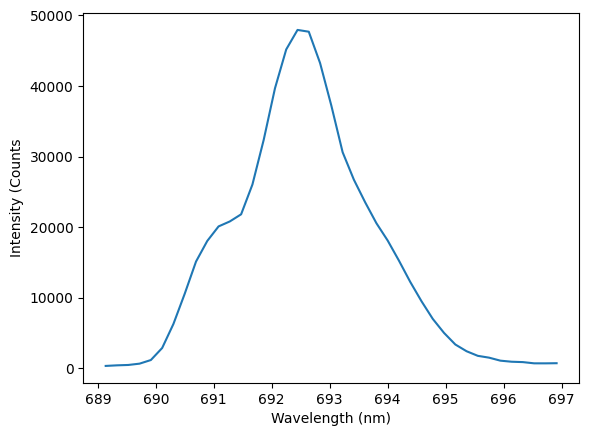

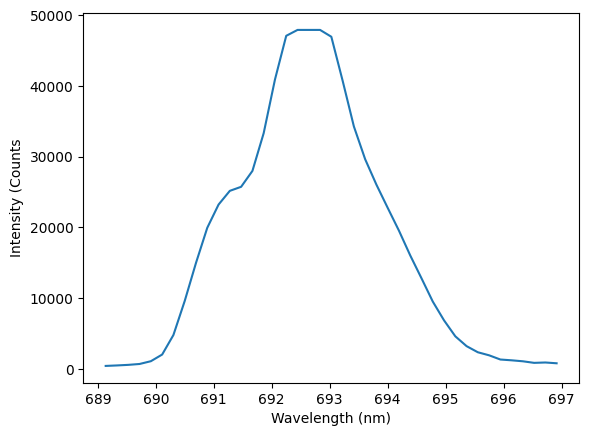

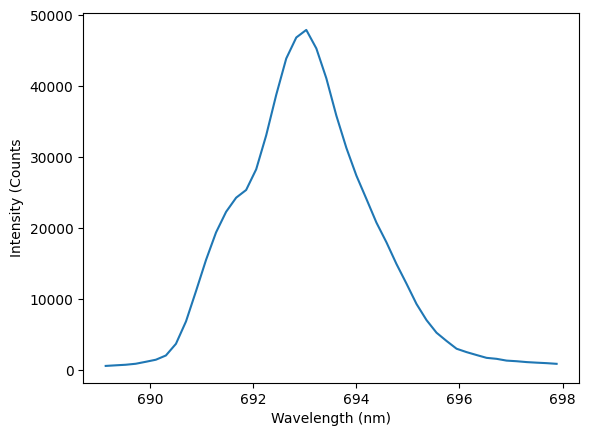

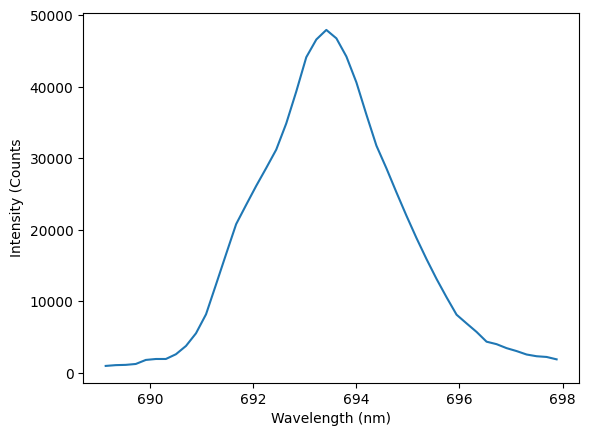

In [30]:
# Mask Mono and Ocean optics

mask_min_ocean = 689.1
mask_max_ocean = 697

mask_min_mono = 688.7
mask_max_mono = 697

temps = [77,147,217,298]

mask_min_ocean = [689.1, 689.1, 689.1, 689.1]
mask_max_ocean = [697, 697, 698, 698]
mask_min_mono = [688.7, 688.7, 688.7, 688.7]
mask_max_mono = [697, 697, 698, 699]

x_ocean = [x_ocean_77, x_ocean_147, x_ocean_217, x_ocean_298]
y_ocean = [y_ocean_77, y_ocean_147, y_ocean_217, y_ocean_298]

I_mono = [I_77_mean, I_147_mean, I_217_mean, I_298_mean]
I_mono_err = [I_77_err, I_147_err, I_217_err, I_298_err]

x_ocean_masked = []
y_ocean_masked = []
y_mono_masked = []
y_mono_err_masked = []
wavelengths_masked = []

for xo, yo, I, I_err, min_ocean, max_ocean, min_mono, max_mono in zip(
        x_ocean, y_ocean, I_mono, I_mono_err,
        mask_min_ocean, mask_max_ocean, mask_min_mono, mask_max_mono):

    mask_ocean = (xo >= min_ocean) & (xo <= max_ocean)
    mask_mono  = (wavelengths >= min_mono) & (wavelengths <= max_mono)

    x_ocean_mask = xo[mask_ocean]
    y_ocean_mask = yo[mask_ocean]
    y_mono_mask = I[mask_mono]
    y_mono_err_mask = I_err[mask_mono]

    normalisation_scalefactor_mono = (np.max(y_ocean_77) / np.max(y_mono_mask))
    normalisation_scalefactor_ocean = (np.max(y_ocean_77) / np.max(y_ocean_mask))

    y_ocean_mask = y_ocean_mask*normalisation_scalefactor_ocean

    x_ocean_masked.append(x_ocean_mask)
    y_ocean_masked.append(y_ocean_mask)

    y_mono_mask = y_mono_mask * normalisation_scalefactor_mono
    y_mono_err_mask = y_mono_err_mask * normalisation_scalefactor_mono

    y_mono_masked.append(y_mono_mask)
    y_mono_err_masked.append(y_mono_err_mask)
    wavelengths_masked.append(wavelengths[mask_mono])

print(f"----- Mono -----")
for i in range(len(y_mono_masked)):
    plt.figure(1)
    plt.plot(wavelengths_masked[i], y_mono_masked[i])
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Intensity (Counts")
    plt.show()

print(f"----- Ocean -----")

for i in range(len(y_ocean_masked)):
    plt.figure(1)
    plt.plot(x_ocean_masked[i], y_ocean_masked[i])
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Intensity (Counts")
    plt.show()

# Fitting Mono

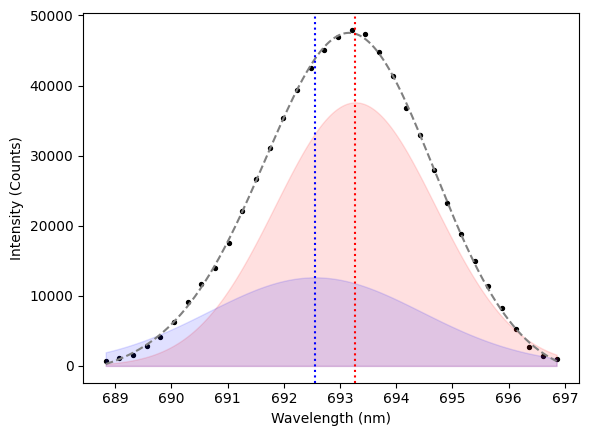

In [44]:
####
# 77
####

A1_guess_mono = np.max(y_mono_masked[0])/2
A2_guess_mono = 0.6 * A1_guess_mono
R1_guess_mono_77 = wavelengths_masked[0][np.argmax(y_mono_masked[0])]
offset_guess_mono_77 = np.min(y_mono_masked[0])

p0_mono_77 = [A1_guess_mono, R1_guess_mono_77, 0.3, 0.3,
              A2_guess_mono, -1.4, 0.3, 0.3, offset_guess_mono_77]

bounds_mono_77 = [
    [0.01*A1_guess_mono, R1_guess_mono_77 - 5, 0, 0,
     0.01*A2_guess_mono, -3, 0, 0, -np.inf], #lower
    [10*A1_guess_mono, R1_guess_mono_77 + 5, np.inf, np.inf,
     10*A2_guess_mono, -0.5, np.inf, np.inf, np.inf] #upper
]

pop_mono_77, cov_mono_77 = curve_fit(voigt_model_double,
                                     wavelengths_masked[0],
                                     y_mono_masked[0],
                                     p0 = p0_mono_77,
                                     bounds = bounds_mono_77,
                                     maxfev = 10000)

x_fit_77 = np.linspace(wavelengths_masked[0][-1], wavelengths_masked[0][0], 10000)

pop_R1_mono_77 = [pop_mono_77[0], pop_mono_77[1], pop_mono_77[2], pop_mono_77[3], 0]
R1_mono_77 = voigt_profile_single(x_fit_77, *pop_R1_mono_77)

pop_R2_mono_77 = [pop_mono_77[4], pop_mono_77[5] + pop_mono_77[1], pop_mono_77[6], pop_mono_77[7], 0]
R2_mono_77 = voigt_profile_single(x_fit_77, *pop_R2_mono_77)

plt.figure(1)
plt.scatter(wavelengths_masked[0], y_mono_masked[0], marker = 'o', color = "black", s = 8)
plt.plot(x_fit_77, voigt_model_double(x_fit_77, *pop_mono_77), color = "grey", linestyle = "--")

plt.fill_between(x_fit_77, R1_mono_77, 0 , color = "red", alpha = 0.12)
plt.fill_between(x_fit_77, R2_mono_77, 0 , color = "blue", alpha = 0.12)

plt.axvline(pop_R1_mono_77[1], color = "red", linestyle = ":")
plt.axvline(pop_R2_mono_77[1], color = "blue", linestyle = ":")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (Counts)")
plt.show()

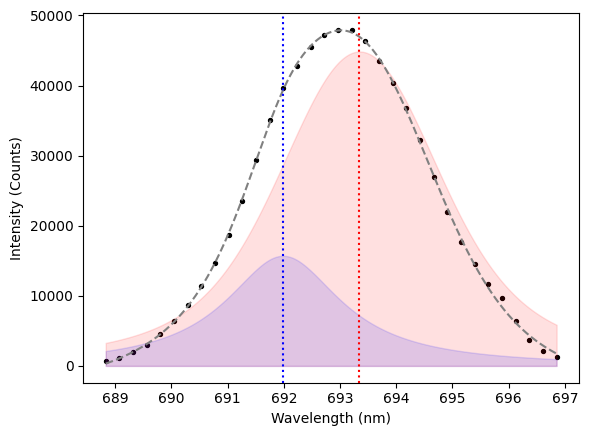

In [45]:
####
# 147
####

A1_guess_mono = np.max(y_mono_masked[1])/2
A2_guess_mono = 0.6 * A1_guess_mono
R1_guess_mono_147 = wavelengths_masked[1][np.argmax(y_mono_masked[1])]
offset_guess_mono_147 = np.min(y_mono_masked[1])

p0_mono_147 = [A1_guess_mono, R1_guess_mono_147, 0.3, 0.3,
              A2_guess_mono, -1.4, 0.3, 0.3, offset_guess_mono_147]

bounds_mono_147 = [
    [0.01*A1_guess_mono, R1_guess_mono_147 - 5, 0, 0,
     0.01*A2_guess_mono, -3, 0, 0, -np.inf], #lower
    [10*A1_guess_mono, R1_guess_mono_147 + 5, np.inf, np.inf,
     10*A2_guess_mono, -0.5, np.inf, np.inf, np.inf] #upper
]

pop_mono_147, cov_mono_147 = curve_fit(voigt_model_double,
                                     wavelengths_masked[1],
                                     y_mono_masked[1],
                                     p0 = p0_mono_147,
                                     bounds = bounds_mono_147,
                                     maxfev = 10000)

x_fit_147 = np.linspace(wavelengths_masked[1][-1], wavelengths_masked[1][0], 10000)

pop_R1_mono_147 = [pop_mono_147[0], pop_mono_147[1], pop_mono_147[2], pop_mono_147[3], 0]
R1_mono_147 = voigt_profile_single(x_fit_147, *pop_R1_mono_147)

pop_R2_mono_147 = [pop_mono_147[4], pop_mono_147[5] + pop_mono_147[1], pop_mono_147[6], pop_mono_147[7], 0]
R2_mono_147 = voigt_profile_single(x_fit_147, *pop_R2_mono_147)

plt.figure(1)
plt.scatter(wavelengths_masked[1], y_mono_masked[1], marker = 'o', color = "black", s = 8)
plt.plot(x_fit_147, voigt_model_double(x_fit_147, *pop_mono_147), color = "grey", linestyle = "--")

plt.fill_between(x_fit_147, R1_mono_147, 0 , color = "red", alpha = 0.12)
plt.fill_between(x_fit_147, R2_mono_147, 0 , color = "blue", alpha = 0.12)

plt.axvline(pop_R1_mono_147[1], color = "red", linestyle = ":")
plt.axvline(pop_R2_mono_147[1], color = "blue", linestyle = ":")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (Counts)")
plt.show()

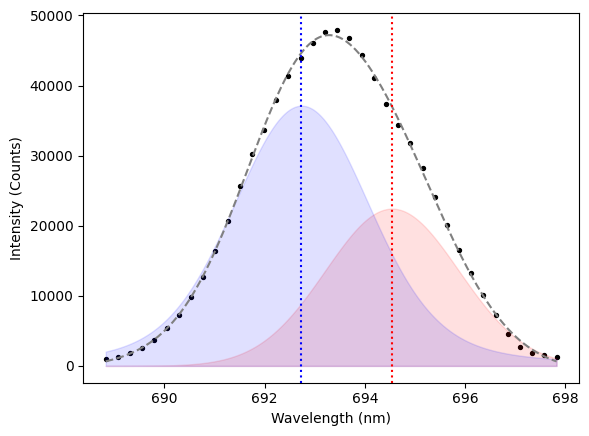

In [46]:
####
# 217
####

A1_guess_mono = np.max(y_mono_masked[2])/2
A2_guess_mono = 0.6 * A1_guess_mono
R1_guess_mono_217 = wavelengths_masked[2][np.argmax(y_mono_masked[2])]
offset_guess_mono_217 = np.min(y_mono_masked[2])

p0_mono_217 = [A1_guess_mono, R1_guess_mono_217, 0.3, 0.3,
              A2_guess_mono, -1.4, 0.3, 0.3, offset_guess_mono_217]

bounds_mono_217 = [
    [0.01*A1_guess_mono, R1_guess_mono_217 - 5, 0, 0,
     0.01*A2_guess_mono, -3, 0, 0, -np.inf], #lower
    [10*A1_guess_mono, R1_guess_mono_217 + 5, np.inf, np.inf,
     10*A2_guess_mono, -0.5, np.inf, np.inf, np.inf] #upper
]

pop_mono_217, cov_mono_217 = curve_fit(voigt_model_double,
                                     wavelengths_masked[2],
                                     y_mono_masked[2],
                                     p0 = p0_mono_217,
                                     bounds = bounds_mono_217,
                                     maxfev = 10000)

x_fit_217 = np.linspace(wavelengths_masked[2][-1], wavelengths_masked[2][0], 10000)

pop_R1_mono_217 = [pop_mono_217[0], pop_mono_217[1], pop_mono_217[2], pop_mono_217[3], 0]
R1_mono_217 = voigt_profile_single(x_fit_217, *pop_R1_mono_217)

pop_R2_mono_217 = [pop_mono_217[4], pop_mono_217[5] + pop_mono_217[1], pop_mono_217[6], pop_mono_217[7], 0]
R2_mono_217 = voigt_profile_single(x_fit_217, *pop_R2_mono_217)

plt.figure(1)
plt.scatter(wavelengths_masked[2], y_mono_masked[2], marker = 'o', color = "black", s = 8)
plt.plot(x_fit_217, voigt_model_double(x_fit_217, *pop_mono_217), color = "grey", linestyle = "--")

plt.fill_between(x_fit_217, R1_mono_217, 0 , color = "red", alpha = 0.12)
plt.fill_between(x_fit_217, R2_mono_217, 0 , color = "blue", alpha = 0.12)

plt.axvline(pop_R1_mono_217[1], color = "red", linestyle = ":")
plt.axvline(pop_R2_mono_217[1], color = "blue", linestyle = ":")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (Counts)")
plt.show()

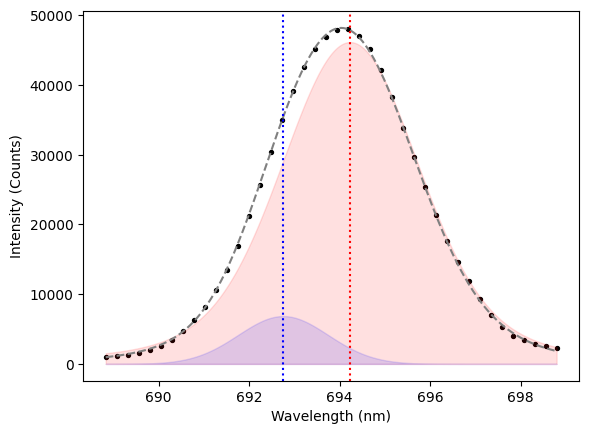

In [47]:
####
# 298
####

A1_guess_mono = np.max(y_mono_masked[3]) / 2
A2_guess_mono = 0.6 * A1_guess_mono
R1_guess_mono_298 = wavelengths_masked[3][np.argmax(y_mono_masked[3])]
offset_guess_mono_298 = np.min(y_mono_masked[3])

p0_mono_298 = [A1_guess_mono, R1_guess_mono_298, 0.3, 0.3,
               A2_guess_mono, -1.4, 0.3, 0.3, offset_guess_mono_298]

bounds_mono_298 = [
    [0.01 * A1_guess_mono, R1_guess_mono_298 - 5, 0, 0,
     0.01 * A2_guess_mono, -3, 0, 0, -np.inf],  #lower
    [10 * A1_guess_mono, R1_guess_mono_298 + 5, np.inf, np.inf,
     10 * A2_guess_mono, -0.5, np.inf, np.inf, np.inf]  #upper
]

pop_mono_298, cov_mono_298 = curve_fit(voigt_model_double,
                                       wavelengths_masked[3],
                                       y_mono_masked[3],
                                       p0=p0_mono_298,
                                       bounds=bounds_mono_298,
                                       maxfev=10000)

x_fit_298 = np.linspace(wavelengths_masked[3][-1], wavelengths_masked[3][0], 10000)

pop_R1_mono_298 = [pop_mono_298[0], pop_mono_298[1], pop_mono_298[2], pop_mono_298[3], 0]
R1_mono_298 = voigt_profile_single(x_fit_298, *pop_R1_mono_298)

pop_R2_mono_298 = [pop_mono_298[4], pop_mono_298[5] + pop_mono_298[1], pop_mono_298[6], pop_mono_298[7], 0]
R2_mono_298 = voigt_profile_single(x_fit_298, *pop_R2_mono_298)

plt.figure(1)
plt.scatter(wavelengths_masked[3], y_mono_masked[3], marker='o', color="black", s=8)
plt.plot(x_fit_298, voigt_model_double(x_fit_298, *pop_mono_298), color="grey", linestyle="--")

plt.fill_between(x_fit_298, R1_mono_298, 0, color="red", alpha=0.12)
plt.fill_between(x_fit_298, R2_mono_298, 0, color="blue", alpha=0.12)

plt.axvline(pop_R1_mono_298[1], color="red", linestyle=":")
plt.axvline(pop_R2_mono_298[1], color="blue", linestyle=":")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (Counts)")
plt.show()